In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
adata=sc.read_h5ad('Full_obj_log_counts_soupx_v2.h5ad')

In [4]:
adata.X

<428469x30535 sparse matrix of type '<class 'numpy.float32'>'
	with 755560015 stored elements in Compressed Sparse Row format>

In [5]:
adata

AnnData object with n_obs × n_vars = 428469 × 30535
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'Integrated_05'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'Integrated_colors', 'category2_colors', 'category_colors', "dendrogram_['Integrated']", "dendrogram_['Integrated_05']", 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'

In [6]:
adata.obs

,Sample name,Diagnosis,Age,sample name,Region code,Fraction,Gender,Region,10X,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_scores,predicted_doublets,category,Age_group,Integrated_05
AAACCTGAGAACAACT-1-4918STDY7333456,T036,Pediatric healthy,4,T036-TIL-SC-EPCAMP,TIL,SC-EPCAMP,M,SmallInt,3',4918STDY7333456,968,968,1912.793579,46.228199,2.416790,0.016442,False,B cells,Pediatric,DZ GC cell
AAACCTGAGCGATATA-1-4918STDY7333456,T036,Pediatric healthy,4,T036-TIL-SC-EPCAMP,TIL,SC-EPCAMP,M,SmallInt,3',4918STDY7333456,693,693,2152.089355,0.122579,0.005696,0.027389,False,B cells,Pediatric,Cycling B cell
AAACCTGAGGAGTTTA-1-4918STDY7333456,T036,Pediatric healthy,4,T036-TIL-SC-EPCAMP,TIL,SC-EPCAMP,M,SmallInt,3',4918STDY7333456,720,720,1686.883423,80.195816,4.754082,0.014817,False,T cells,Pediatric,gdT
AAACCTGAGTATCTCG-1-4918STDY7333456,T036,Pediatric healthy,4,T036-TIL-SC-EPCAMP,TIL,SC-EPCAMP,M,SmallInt,3',4918STDY7333456,746,746,2135.183838,104.506760,4.894509,0.039416,False,B cells,Pediatric,Memory B
AAACCTGAGTGACTCT-1-4918STDY7333456,T036,Pediatric healthy,4,T036-TIL-SC-EPCAMP,TIL,SC-EPCAMP,M,SmallInt,3',4918STDY7333456,1227,1227,3103.050293,95.846077,3.088770,0.025763,False,B cells,Pediatric,DZ GC cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTTCAACACGT-1-WTDAtest7770719,A30 (398B),Healthy adult,20-25,A30-SCL-6-SC-45N-2,SCL,SC-45N,F,LargeInt,3',WTDAtest7770719,1821,1821,4838.415039,144.966095,2.996148,0.027510,False,Mesenchymal,Adult,Stromal 1 (CCL11+)
TTTGGTTTCCAAATGC-1-WTDAtest7770719,A30 (398B),Healthy adult,20-25,A30-SCL-6-SC-45N-2,SCL,SC-45N,F,LargeInt,3',WTDAtest7770719,1814,1814,5337.013672,85.408028,1.600296,0.014349,False,Mesenchymal,Adult,Stromal 1 (CCL11+)
TTTGGTTTCGGCGGTT-1-WTDAtest7770719,A30 (398B),Healthy adult,20-25,A30-SCL-6-SC-45N-2,SCL,SC-45N,F,LargeInt,3',WTDAtest7770719,6418,6418,48142.085938,7198.451172,14.952512,0.072750,False,Epithelial,Adult,Colonocyte
TTTGTCAGTGAAAGAG-1-WTDAtest7770719,A30 (398B),Healthy adult,20-25,A30-SCL-6-SC-45N-2,SCL,SC-45N,F,LargeInt,3',WTDAtest7770719,2578,2578,10848.547852,600.362671,5.534037,0.091348,False,Epithelial,Adult,Stem cells


In [7]:
adata_5p=adata[adata.obs['10X'].isin(["5'"])]
adata_5p

View of AnnData object with n_obs × n_vars = 200905 × 30535
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'Integrated_05'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'Integrated_colors', 'category2_colors', 'category_colors', "dendrogram_['Integrated']", "dendrogram_['Integrated_05']", 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'

In [8]:
adata_5p.obs

,Sample name,Diagnosis,Age,sample name,Region code,Fraction,Gender,Region,10X,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_scores,predicted_doublets,category,Age_group,Integrated_05
AAACGGGCAGTCAGAG-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,5825,5825,39552.324219,10306.581055,26.058092,0.031864,False,Epithelial,Adult,TA
AAAGCAATCCGTTGTC-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,3754,3754,18149.621094,7506.814453,41.360725,0.209135,False,Epithelial,Adult,TA
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,1742,1742,15017.241211,301.189819,2.005627,0.082664,False,Plasma cells,Adult,IgA plasma cell
AAATGCCTCGACAGCC-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,1432,1432,2660.692627,92.005714,3.457961,0.017177,False,Mesenchymal,Adult,Stromal 1 (CCL11+)
AACACGTAGAGCCCAA-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,528,528,1414.935181,366.631927,25.911570,0.023582,False,Plasma cells,Adult,IgA plasma cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCAAACCAC-1-FCA_gut9456326,BRC2259,fetal,7.4Wk,C75-FSI-0-SC-2 G,FPIL,SC,F,SmallInt,5',FCA_gut9456326,2629,2629,8520.518555,300.756012,3.529785,0.025570,False,Mesenchymal,First trim,Mesoderm 1 (HAND1+)
TTTGTCATCCGAACGC-1-FCA_gut9456326,BRC2259,fetal,7.4Wk,C75-FSI-0-SC-2 G,FPIL,SC,F,SmallInt,5',FCA_gut9456326,5219,5219,28273.031250,657.837402,2.326731,0.056524,False,Epithelial,First trim,Distal progenitor
TTTGTCATCTATGTGG-1-FCA_gut9456326,BRC2259,fetal,7.4Wk,C75-FSI-0-SC-2 G,FPIL,SC,F,SmallInt,5',FCA_gut9456326,1939,1939,5242.168457,129.367722,2.467829,0.082406,False,Mesenchymal,First trim,Mesoderm 1 (HAND1+)
TTTGTCATCTCGAGTA-1-FCA_gut9456326,BRC2259,fetal,7.4Wk,C75-FSI-0-SC-2 G,FPIL,SC,F,SmallInt,5',FCA_gut9456326,2706,2706,7774.051758,413.076782,5.313533,0.134211,False,Mesenchymal,First trim,Mesoderm 1 (HAND1+)


In [9]:
adata_5p.obs.Age_group.value_counts()

Adult              71863
Second trim        65300
First trim         45203
Adult_MLN          10365
Second trim_MLN     8174
Name: Age_group, dtype: int64

In [10]:
adata_5p.obs.Age.value_counts()

11.1Wk    34177
15Wk      31569
16Wk      27859
65-70     27502
25-30     21940
45-50     14430
17Wk      14046
7.4Wk     11026
70-75     10120
60-65      8236
Name: Age, dtype: int64

In [11]:
adata_5p_ad=adata_5p[adata_5p.obs['Age_group'].isin(["Adult", "Adult_MLN"])]
adata_5p_ad

View of AnnData object with n_obs × n_vars = 82228 × 30535
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'Integrated_05'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'Integrated_colors', 'category2_colors', 'category_colors', "dendrogram_['Integrated']", "dendrogram_['Integrated_05']", 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'

In [12]:
adata_5p_ad.obs

,Sample name,Diagnosis,Age,sample name,Region code,Fraction,Gender,Region,10X,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_scores,predicted_doublets,category,Age_group,Integrated_05
AAACGGGCAGTCAGAG-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,5825,5825,39552.324219,10306.581055,26.058092,0.031864,False,Epithelial,Adult,TA
AAAGCAATCCGTTGTC-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,3754,3754,18149.621094,7506.814453,41.360725,0.209135,False,Epithelial,Adult,TA
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,1742,1742,15017.241211,301.189819,2.005627,0.082664,False,Plasma cells,Adult,IgA plasma cell
AAATGCCTCGACAGCC-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,1432,1432,2660.692627,92.005714,3.457961,0.017177,False,Mesenchymal,Adult,Stromal 1 (CCL11+)
AACACGTAGAGCCCAA-1-Human_colon_16S8000511,A32 (411C),Healthy adult,25-30,A32-SCL-0-SC-45N-1,SCL,SC-45N,M,LargeInt,5',Human_colon_16S8000511,528,528,1414.935181,366.631927,25.911570,0.023582,False,Plasma cells,Adult,IgA plasma cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAAGGTTTC-1-Human_colon_16S8117828,A26 (386C),Healthy adult,70-75,A26-MLN-0-SC-1,MLN,SC,F,lymph node,5',Human_colon_16S8117828,2468,2468,5860.578613,289.560822,4.940823,0.078431,False,T cells,Adult_MLN,ILC3
TTTGTCACAGGAACGT-1-Human_colon_16S8117828,A26 (386C),Healthy adult,70-75,A26-MLN-0-SC-1,MLN,SC,F,lymph node,5',Human_colon_16S8117828,1936,1936,6743.875977,190.754028,2.828552,0.029475,False,T cells,Adult_MLN,SELL+ CD4 T
TTTGTCAGTTGTCTTT-1-Human_colon_16S8117828,A26 (386C),Healthy adult,70-75,A26-MLN-0-SC-1,MLN,SC,F,lymph node,5',Human_colon_16S8117828,1268,1268,2914.672363,162.478149,5.574491,0.074090,False,B cells,Adult_MLN,Memory B
TTTGTCATCGTTTATC-1-Human_colon_16S8117828,A26 (386C),Healthy adult,70-75,A26-MLN-0-SC-1,MLN,SC,F,lymph node,5',Human_colon_16S8117828,1625,1625,4175.837891,351.605438,8.419997,0.084799,False,T cells,Adult_MLN,Treg


In [13]:
adata_5p_ad.obs['Sample name'].value_counts()

A34 (417C)    27502
A32 (411C)    21940
A39 (440C)    14430
A26 (386C)    10120
A38 (432C)     8236
Name: Sample name, dtype: int64

In [14]:
remapped_genes=pd.read_csv('Cumulus_VersionB/Merged.unknown-rna.h5ad.p14_p16_p15_ANRIL_rawCounts.txt', sep='\t', index_col=0)

In [15]:
remapped_genes

,cell_id,match_id,Channel,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1
barcodekey,,,,,,,
FCA_gut8015057-AAACCTGAGACCTAGG,AAACCTGAGACCTAGG,AAACCTGAGACCTAGG-1-FCA_gut8015057,FCA_gut8015057,0.0,0.0,0.0,0.0
FCA_gut8015057-AAACCTGAGAGACTAT,AAACCTGAGAGACTAT,AAACCTGAGAGACTAT-1-FCA_gut8015057,FCA_gut8015057,0.0,0.0,0.0,0.0
FCA_gut8015057-AAACCTGAGAGCAATT,AAACCTGAGAGCAATT,AAACCTGAGAGCAATT-1-FCA_gut8015057,FCA_gut8015057,0.0,0.0,0.0,0.0
FCA_gut8015057-AAACCTGAGAGGGCTT,AAACCTGAGAGGGCTT,AAACCTGAGAGGGCTT-1-FCA_gut8015057,FCA_gut8015057,0.0,0.0,0.0,0.0
FCA_gut8015057-AAACCTGAGCCAGTAG,AAACCTGAGCCAGTAG,AAACCTGAGCCAGTAG-1-FCA_gut8015057,FCA_gut8015057,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
Human_colon_16S8159194-TTTGTCATCCAGAAGG,TTTGTCATCCAGAAGG,TTTGTCATCCAGAAGG-1-Human_colon_16S8159194,Human_colon_16S8159194,0.0,0.0,0.0,0.0
Human_colon_16S8159194-TTTGTCATCCGCGCAA,TTTGTCATCCGCGCAA,TTTGTCATCCGCGCAA-1-Human_colon_16S8159194,Human_colon_16S8159194,0.0,0.0,0.0,0.0
Human_colon_16S8159194-TTTGTCATCCTCAATT,TTTGTCATCCTCAATT,TTTGTCATCCTCAATT-1-Human_colon_16S8159194,Human_colon_16S8159194,0.0,0.0,0.0,0.0


In [16]:
remapped_genes.index=remapped_genes.match_id

In [17]:
#change the names of the genes so it is clear when showing the remapping and when showing the original data

In [18]:
adata_5p_ad.obs['CDKN2A_p14']=remapped_genes['CDKN2A_p14']
adata_5p_ad.obs['CDKN2A_p16']=remapped_genes['CDKN2A_p16']
adata_5p_ad.obs['CDKN2B_p15']=remapped_genes['CDKN2B']
adata_5p_ad.obs['CDKN2BAS1_ANRIL']=remapped_genes['CDKN2B-AS1']


/local/scratch/53150500.1.broad/ipykernel_90972/4261563319.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5p_ad.obs['CDKN2A_p14']=remapped_genes['CDKN2A_p14']


In [19]:
adata_5p_ad.obs.CDKN2A_p14.value_counts()

0.0    81005
1.0     1118
2.0       84
3.0       15
4.0        4
5.0        2
Name: CDKN2A_p14, dtype: int64

In [20]:
adata_5p_ad.obs.CDKN2A_p16.value_counts()

0.0    82065
1.0      136
2.0       18
3.0        4
4.0        2
6.0        1
5.0        1
8.0        1
Name: CDKN2A_p16, dtype: int64

In [21]:
adata_5p_ad.obs.CDKN2B_p15.value_counts()

0.0     71290
1.0      6734
2.0      2114
3.0       974
4.0       460
5.0       297
6.0       139
7.0        95
8.0        46
9.0        34
10.0       13
12.0       10
11.0        7
15.0        5
14.0        4
13.0        3
20.0        1
17.0        1
21.0        1
Name: CDKN2B_p15, dtype: int64

In [22]:
adata_5p_ad.obs.CDKN2BAS1_ANRIL.value_counts()

0.0     74478
1.0      3849
2.0      1252
3.0       700
4.0       454
5.0       326
6.0       224
7.0       187
8.0       144
9.0       118
10.0       98
11.0       72
12.0       65
13.0       50
14.0       47
15.0       33
17.0       23
20.0       17
16.0       16
18.0       14
19.0       11
21.0        7
22.0        7
24.0        5
23.0        5
26.0        5
30.0        3
28.0        3
31.0        2
29.0        2
25.0        2
27.0        2
32.0        1
42.0        1
68.0        1
36.0        1
41.0        1
34.0        1
33.0        1
Name: CDKN2BAS1_ANRIL, dtype: int64

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


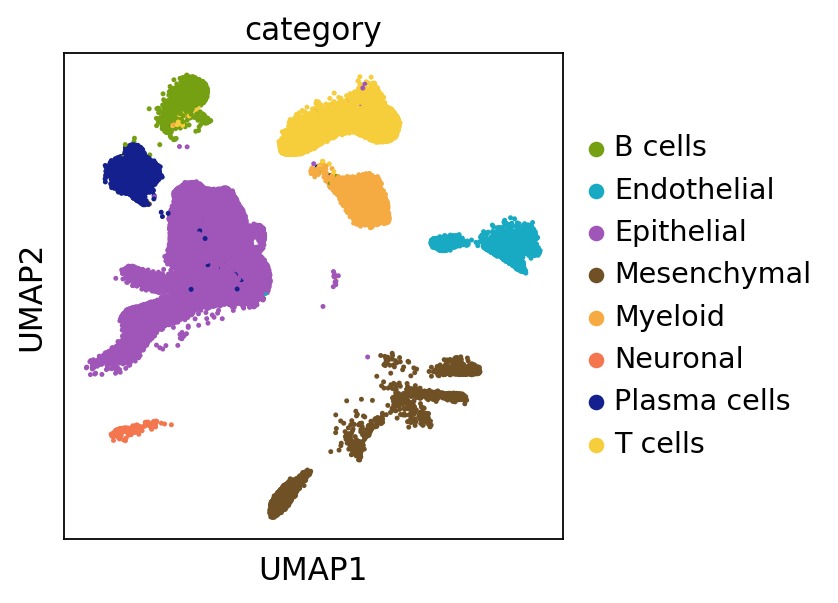

In [23]:
sc.pl.umap(adata_5p_ad, color=['category'], size=20, save="figures/Elmentaite_5prime_onlyAdult_CellTypes_forGH.pdf")

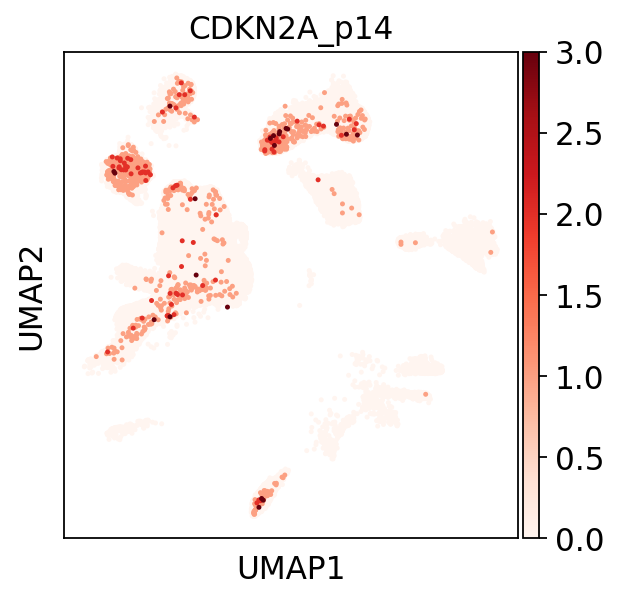

In [24]:
sc.pl.umap(adata_5p_ad, color=['CDKN2A_p14'], color_map='Reds', vmax='p99.99', size=20, save="figures/Elmentaite_5prime_onlyAdult_CellTypes_p14_RawCounts_forGH.pdf")

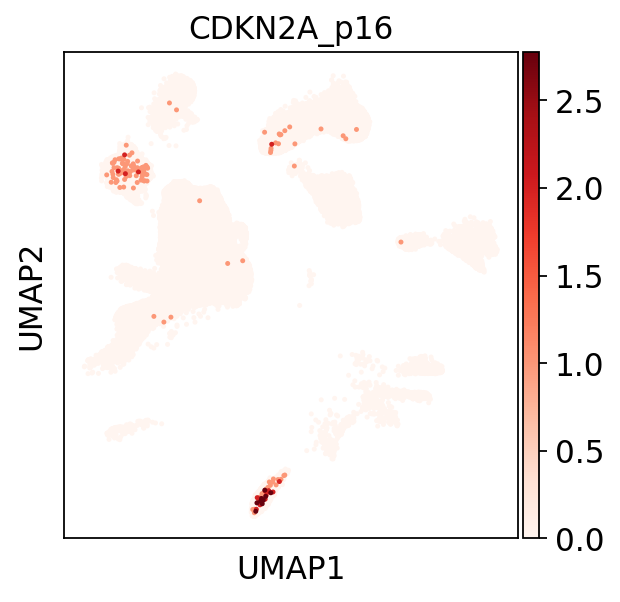

In [25]:
sc.pl.umap(adata_5p_ad, color=['CDKN2A_p16'], color_map='Reds', vmax='p99.99', size=20, save="figures/Elmentaite_5prime_onlyAdult_CellTypes_p16_RawCounts_forGH.pdf")

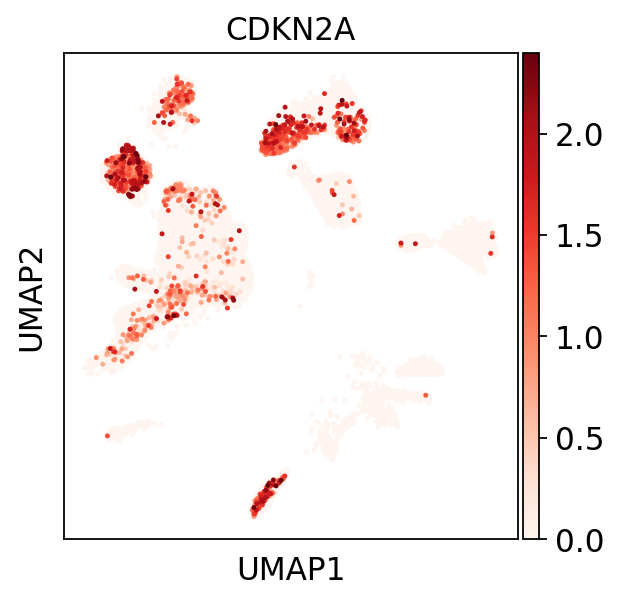

In [26]:
sc.pl.umap(adata_5p_ad, color=['CDKN2A'], color_map='Reds', vmax='p99.99', size=20, save="figures/Elmentaite_5prime_onlyAdult_CDKN2A_fromObject.pdf")

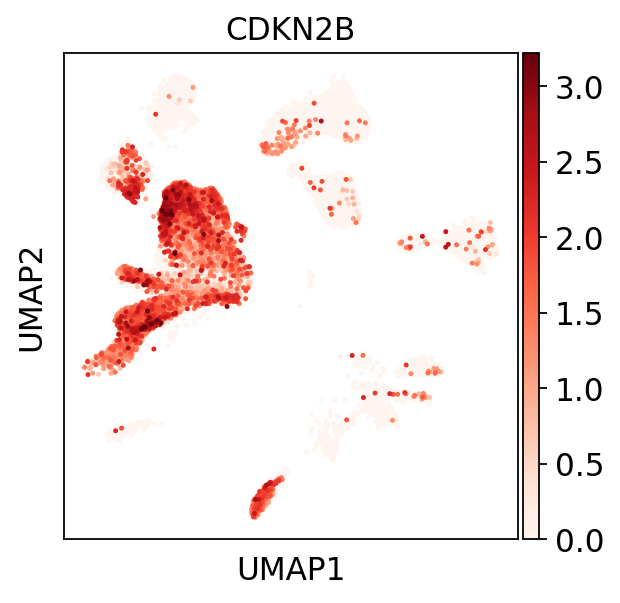

In [27]:
sc.pl.umap(adata_5p_ad, color=['CDKN2B'], color_map='Reds', vmax='p99.99', size=20, save="figures/Elmentaite_5prime_onlyAdult_CDKN2B_fromObject.pdf")

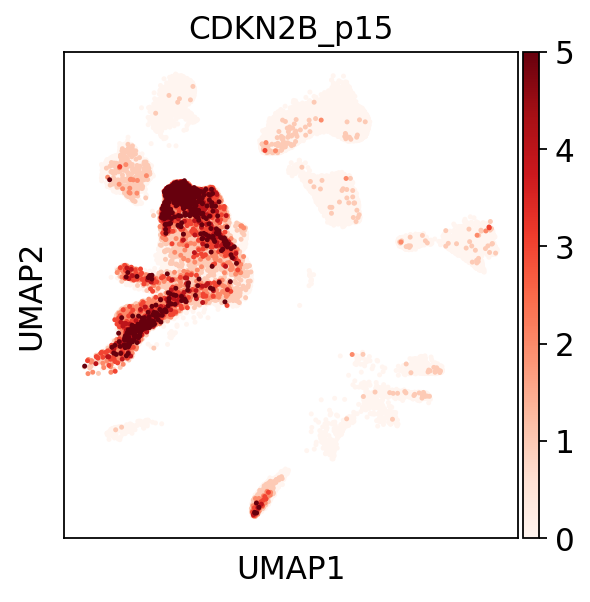

In [28]:
sc.pl.umap(adata_5p_ad, color=['CDKN2B_p15'], color_map='Reds', vmax='p99.5', size=20, save="figures/Elmentaite_5prime_onlyAdult_CDKN2B_p15_RawCounts_fromRemapping.pdf")

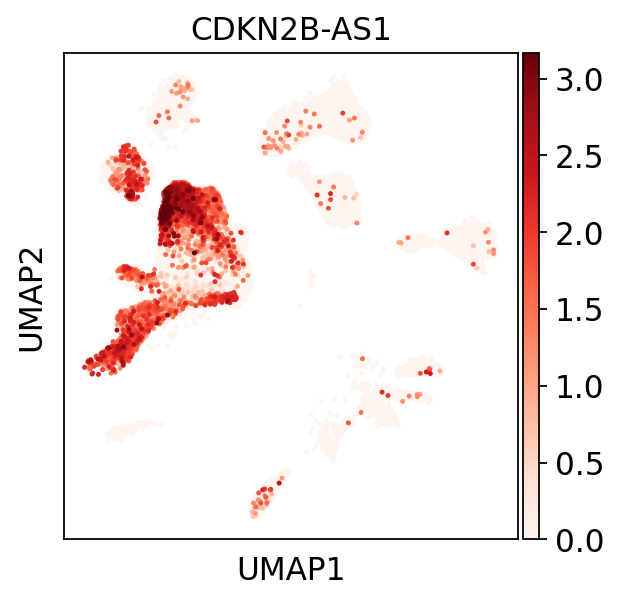

In [29]:
sc.pl.umap(adata_5p_ad, color=['CDKN2B-AS1'], color_map='Reds', vmax='p99.95', size=20,  save="figures/Elmentaite_5prime_onlyAdult_CDKN2B-AS1_fromObject.pdf")

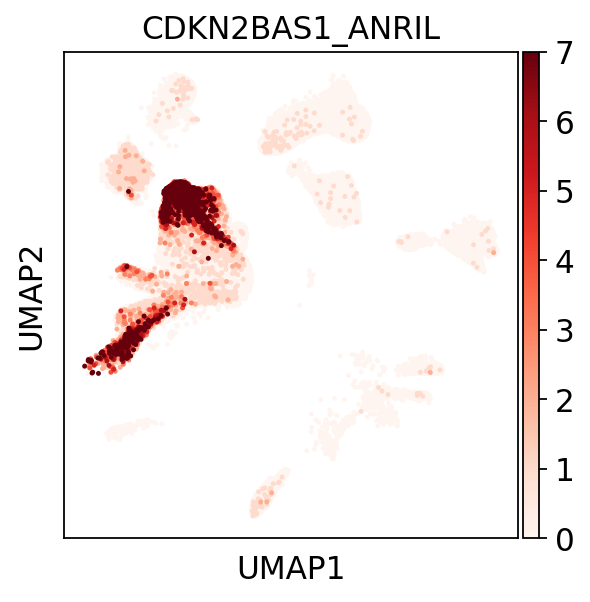

In [30]:
sc.pl.umap(adata_5p_ad, color=['CDKN2BAS1_ANRIL'], color_map='Reds', vmax='p99', size=20,  save="figures/Elmentaite_5prime_onlyAdult_CDKN2B-AS1_RawCounts_fromRemapping.pdf")

In [31]:
adata_5p_ad

AnnData object with n_obs × n_vars = 82228 × 30535
    obs: 'Sample name', 'Diagnosis', 'Age', 'sample name', 'Region code', 'Fraction', 'Gender', 'Region', '10X', 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_scores', 'predicted_doublets', 'category', 'Age_group', 'Integrated_05', 'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B_p15', 'CDKN2BAS1_ANRIL'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'Integrated_colors', 'category2_colors', 'category_colors', "dendrogram_['Integrated']", "dendrogram_['Integrated_05']", 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'

In [32]:
genedf_adult = sc.get.obs_df(adata_5p_ad,
        keys=["Sample name", "Region", "Region code", "Fraction",  
              "category",'Integrated_05', 'Age_group', "Age", "Diagnosis", 
              'CDKN2A', 'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B_p15', 'CDKN2BAS1_ANRIL', 'CDKN2B', 'CDKN2B-AS1']
    )

In [33]:
genedf_adult

,Sample name,Region,Region code,Fraction,category,Integrated_05,Age_group,Age,Diagnosis,CDKN2A,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL,CDKN2B,CDKN2B-AS1
AAACGGGCAGTCAGAG-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Epithelial,TA,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAGCAATCCGTTGTC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Epithelial,TA,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAATGCCTCGACAGCC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Mesenchymal,Stromal 1 (CCL11+),Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACACGTAGAGCCCAA-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAAGGTTTC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,ILC3,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCACAGGAACGT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,SELL+ CD4 T,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCAGTTGTCTTT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,B cells,Memory B,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTCATCGTTTATC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,Treg,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
pd.crosstab(genedf_adult['Age'], genedf_adult['Sample name'])


Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
Age,,,,,
25-30,0,21940,0,0,0
45-50,0,0,0,0,14430
60-65,0,0,0,8236,0
65-70,0,0,27502,0,0
70-75,10120,0,0,0,0


In [35]:
genedf_adult['Sample name'].value_counts()

A34 (417C)    27502
A32 (411C)    21940
A39 (440C)    14430
A26 (386C)    10120
A38 (432C)     8236
Name: Sample name, dtype: int64

In [36]:
genedf_adult['Age'].value_counts()

65-70    27502
25-30    21940
45-50    14430
70-75    10120
60-65     8236
Name: Age, dtype: int64

In [37]:
genedf_adult['Region code']

AAACGGGCAGTCAGAG-1-Human_colon_16S8000511    SCL
AAAGCAATCCGTTGTC-1-Human_colon_16S8000511    SCL
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511    SCL
AAATGCCTCGACAGCC-1-Human_colon_16S8000511    SCL
AACACGTAGAGCCCAA-1-Human_colon_16S8000511    SCL
                                            ... 
TTTGTCACAAGGTTTC-1-Human_colon_16S8117828    MLN
TTTGTCACAGGAACGT-1-Human_colon_16S8117828    MLN
TTTGTCAGTTGTCTTT-1-Human_colon_16S8117828    MLN
TTTGTCATCGTTTATC-1-Human_colon_16S8117828    MLN
TTTGTCATCTTGAGGT-1-Human_colon_16S8117828    MLN
Name: Region code, Length: 82228, dtype: category
Categories (13, object): ['ACL', 'APD', 'CAE', 'DCL', ..., 'MLN', 'REC', 'SCL', 'TCL']

In [38]:
genedf_adult['Region code'].value_counts()

SCL     11949
TCL     11802
MLN     10365
ILE     10081
ACL      7007
CAE      6934
DUO      6460
JEJ      4113
REC      4049
DCL      3807
ILE2     2983
APD      2231
ILE1      447
Name: Region code, dtype: int64

In [39]:
pd.crosstab(genedf_adult['Region code'], genedf_adult['Sample name'])


Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
Region code,,,,,
ACL,0,0,3488,2197,1322
APD,0,859,468,363,541
CAE,2165,1593,2040,885,251
DCL,0,0,2628,888,291
DUO,0,0,5686,774,0
ILE,0,8739,1342,0,0
ILE1,0,0,0,0,447
ILE2,0,0,2374,0,609
JEJ,0,0,892,767,2454


In [40]:
## Sample names
#A34 (417C)    27502
#A32 (411C)    21940
#A39 (440C)    14430
#A26 (386C)    10120
#A38 (432C)     8236


In [41]:
genedf_adult['category2']=genedf_adult['category']
genedf_adult['category2'] = genedf_adult['category2'].astype('str')
genedf_adult.loc[genedf_adult['category'].isin(['B cells', 'T cells', 'Plasma cells', 'Myeloid']),'category2'] = 'Immune'


In [45]:
genedf_adult

,Sample name,Region,Region code,Fraction,category,Integrated_05,Age_group,Age,Diagnosis,CDKN2A,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL,CDKN2B,CDKN2B-AS1,category2
AAACGGGCAGTCAGAG-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Epithelial,TA,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Epithelial
AAAGCAATCCGTTGTC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Epithelial,TA,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Epithelial
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune
AAATGCCTCGACAGCC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Mesenchymal,Stromal 1 (CCL11+),Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Mesenchymal
AACACGTAGAGCCCAA-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAAGGTTTC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,ILC3,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCACAGGAACGT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,SELL+ CD4 T,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCAGTTGTCTTT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,B cells,Memory B,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCATCGTTTATC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,Treg,Adult_MLN,70-75,Healthy adult,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Immune


In [47]:
total_counts = genedf_adult.groupby('category2').size()
total_counts

category2
Endothelial     3753
Epithelial     39761
Immune         33311
Mesenchymal     5257
Neuronal         146
dtype: int64

In [42]:
# Count total rows per cell type
total_counts = genedf_adult.groupby('category2').size()

# Count rows where expression > 0 per cell type
above_threshold_p14 = genedf_adult[genedf_adult['CDKN2A_p14'] > 0].groupby('category2').size()

# Calculate percentage of rows > 0 per cell type
percentage_above_threshold_p14 = (above_threshold_p14 / total_counts) * 100
percentage_above_threshold_p14

category2
Endothelial    0.133227
Epithelial     0.671512
Immune         2.701810
Mesenchymal    0.970135
Neuronal            NaN
dtype: float64

In [49]:
900/33311*100

2.7018102128426045

In [48]:
above_threshold_p14

category2
Endothelial      5
Epithelial     267
Immune         900
Mesenchymal     51
dtype: int64

In [43]:
total_counts_bysamp = genedf_adult.pivot_table(index='category2', columns='Sample name', aggfunc='size')
total_counts_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,66,1333,1977,373,4
Epithelial,4412,6457,18829,5159,4904
Immune,5324,11708,4876,1949,9454
Mesenchymal,311,2337,1788,753,68
Neuronal,7,105,32,2,0


In [44]:
above_threshold_p14_bysamp =genedf_adult[genedf_adult['CDKN2A_p14'] > 0].pivot_table(index='category2', columns='Sample name', aggfunc='size', fill_value=0)
above_threshold_p14_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,0,1,1,3,0
Epithelial,61,75,75,24,32
Immune,131,341,102,103,223
Mesenchymal,18,8,5,19,1


In [49]:
24/5159*100

0.4652064353556891

In [50]:
percentage_above_threshold_p14_bysamp=above_threshold_p14_bysamp/total_counts_bysamp*100
percentage_above_threshold_p14_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,0.000000,0.075019,0.050582,0.804290,0.000000
Epithelial,1.382593,1.161530,0.398322,0.465206,0.652529
Immune,2.460556,2.912538,2.091879,5.284761,2.358790
Mesenchymal,5.787781,0.342319,0.279642,2.523240,1.470588
Neuronal,NaN,NaN,NaN,NaN,NaN


In [51]:
grouped_errors_p14_sem = percentage_above_threshold_p14_bysamp.sem(axis=1)
grouped_errors_p14_sem

category2
Endothelial    0.155263
Epithelial     0.195522
Immune         0.581045
Mesenchymal    1.014305
Neuronal            NaN
dtype: float64

In [52]:
# Count rows where Value > threshold per Category
above_threshold_counts_p16 = genedf_adult[genedf_adult['CDKN2A_p16'] > 0].groupby('category2').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_p16 = (above_threshold_counts_p16 / total_counts) * 100
percentage_above_threshold_p16

category2
Endothelial    0.026645
Epithelial     0.015090
Immune         0.318213
Mesenchymal    0.951113
Neuronal            NaN
dtype: float64

In [53]:
# Count rows per Subgroup for each Category
above_threshold_p16_bysamp = genedf_adult[genedf_adult['CDKN2A_p16'] > 0].pivot_table(index='category2', columns='Sample name', aggfunc='size', fill_value=0)
above_threshold_p16_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,0,0,0,1,0
Epithelial,1,1,1,2,1
Immune,16,47,21,11,11
Mesenchymal,11,4,7,28,0


In [54]:
percentage_above_threshold_p16_bysamp=above_threshold_p16_bysamp/total_counts_bysamp*100
percentage_above_threshold_p16_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,0.000000,0.000000,0.000000,0.268097,0.000000
Epithelial,0.022665,0.015487,0.005311,0.038767,0.020392
Immune,0.300526,0.401435,0.430681,0.564392,0.116353
Mesenchymal,3.536977,0.171160,0.391499,3.718459,0.000000
Neuronal,NaN,NaN,NaN,NaN,NaN


In [55]:
grouped_errors_p16_sem = percentage_above_threshold_p16_bysamp.sem(axis=1)
grouped_errors_p16_sem

category2
Endothelial    0.053619
Epithelial     0.005451
Immune         0.074617
Mesenchymal    0.845435
Neuronal            NaN
dtype: float64

In [56]:
# Count rows where Value > threshold per Category
above_threshold_counts_p15 = genedf_adult[genedf_adult['CDKN2B_p15'] > 0].groupby('category2').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_p15 = (above_threshold_counts_p15 / total_counts) * 100
percentage_above_threshold_p15

# Count rows per Subgroup for each Category
above_threshold_p15_bysamp = genedf_adult[genedf_adult['CDKN2B_p15'] > 0].pivot_table(index='category2', columns='Sample name', aggfunc='size', fill_value=0)
above_threshold_p15_bysamp

percentage_above_threshold_p15_bysamp=above_threshold_p15_bysamp/total_counts_bysamp*100
percentage_above_threshold_p15_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,0.000000,1.200300,1.062215,1.876676,0.000000
Epithelial,47.733454,20.892055,13.303946,39.368095,38.947798
Immune,2.160030,1.896139,1.558655,1.539251,0.518299
Mesenchymal,34.083601,5.263158,5.145414,21.513944,23.529412
Neuronal,0.000000,1.904762,0.000000,0.000000,NaN


In [57]:
grouped_errors_p15_sem = percentage_above_threshold_p15_bysamp.sem(axis=1)
grouped_errors_p15_sem

category2
Endothelial    0.364990
Epithelial     6.414901
Immune         0.278867
Mesenchymal    5.608158
Neuronal       0.476190
dtype: float64

In [58]:
# Count rows where Value > threshold per Category
above_threshold_counts_ANRIL = genedf_adult[genedf_adult['CDKN2BAS1_ANRIL'] > 0].groupby('category2').size()

# Calculate percentage of rows > threshold per Category
percentage_above_threshold_ANRIL = (above_threshold_counts_ANRIL / total_counts) * 100
percentage_above_threshold_ANRIL

# Count rows per Subgroup for each Category
above_threshold_counts_ANRIL_bysamp = genedf_adult[genedf_adult['CDKN2BAS1_ANRIL'] > 0].pivot_table(index='category2', columns='Sample name', aggfunc='size', fill_value=0)
above_threshold_counts_ANRIL_bysamp

percentage_above_threshold_ANRIL_bysamp=above_threshold_counts_ANRIL_bysamp/total_counts_bysamp*100
percentage_above_threshold_ANRIL_bysamp


Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category2,,,,,
Endothelial,4.545455,0.375094,0.303490,0.268097,0.000000
Epithelial,41.251133,14.945021,9.294174,26.458616,23.776509
Immune,1.164538,3.143150,1.927810,1.795793,0.507722
Mesenchymal,3.215434,0.727428,1.174497,1.593625,2.941176
Neuronal,NaN,NaN,NaN,NaN,NaN


In [59]:
grouped_errors_ANRIL_sem = percentage_above_threshold_ANRIL_bysamp.sem(axis=1)
grouped_errors_ANRIL_sem

category2
Endothelial    0.864093
Epithelial     5.469442
Immune         0.438845
Mesenchymal    0.490149
Neuronal            NaN
dtype: float64

In [ ]:
percentage_above_threshold_ANRIL_bysamp

In [65]:
percentage_above_threshold_ANRIL

category2
Endothelial     0.399680
Epithelial     17.771183
Immune          1.822221
Mesenchymal     1.179380
Neuronal             NaN
dtype: float64

In [64]:
percentage_above_threshold_ANRIL_bysamp.mean(axis=1)

category2
Endothelial     1.098427
Epithelial     23.145091
Immune          1.707802
Mesenchymal     1.930432
Neuronal             NaN
dtype: float64

In [69]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.style.use('default')

<Figure size 800x480 with 0 Axes>

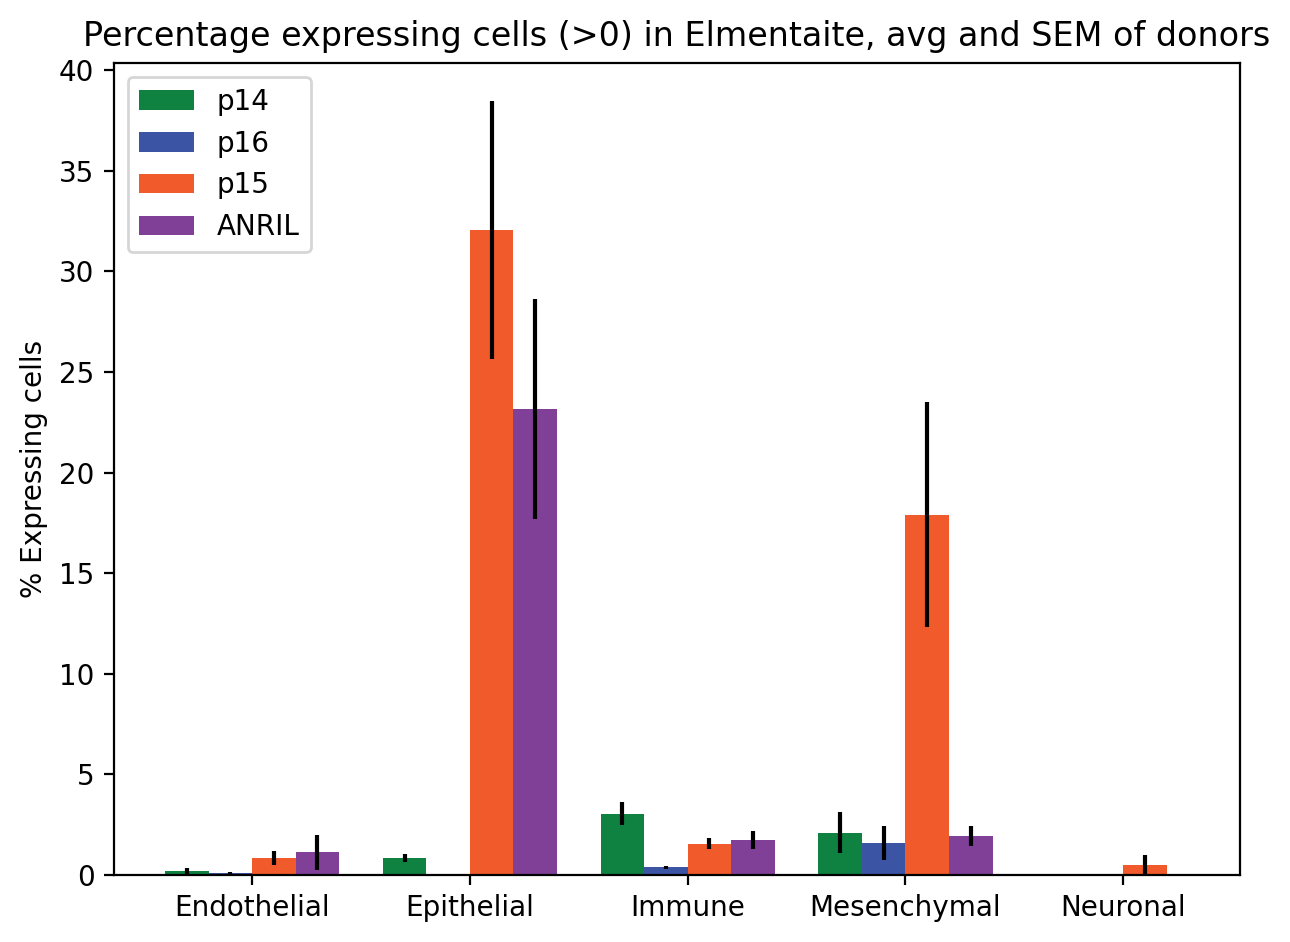

In [74]:
groups = ['Endothelial', 'Epithelial', 'Immune', 'Mesenchymal', 'Neuronal']

# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.2

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(percentage_above_threshold_p14_bysamp.mean(axis=1).values), width, label='p14', yerr=grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(percentage_above_threshold_p16_bysamp.mean(axis=1).values), width, label='p16', yerr=grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(percentage_above_threshold_p15_bysamp.mean(axis=1).values), width, label='p15', yerr=grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(percentage_above_threshold_ANRIL_bysamp.mean(axis=1).values), width, label='ANRIL', yerr=grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('% Expressing cells')
ax.set_title('Percentage expressing cells (>0) in Elmentaite, avg and SEM of donors')
ax.legend()

plt.tight_layout()

plt.savefig("figures/Elmentaite_PercentExpressing_GroupedBarplot_NewCols_avgSEMdonors.pdf", format='pdf', dpi=300)
plt.show()

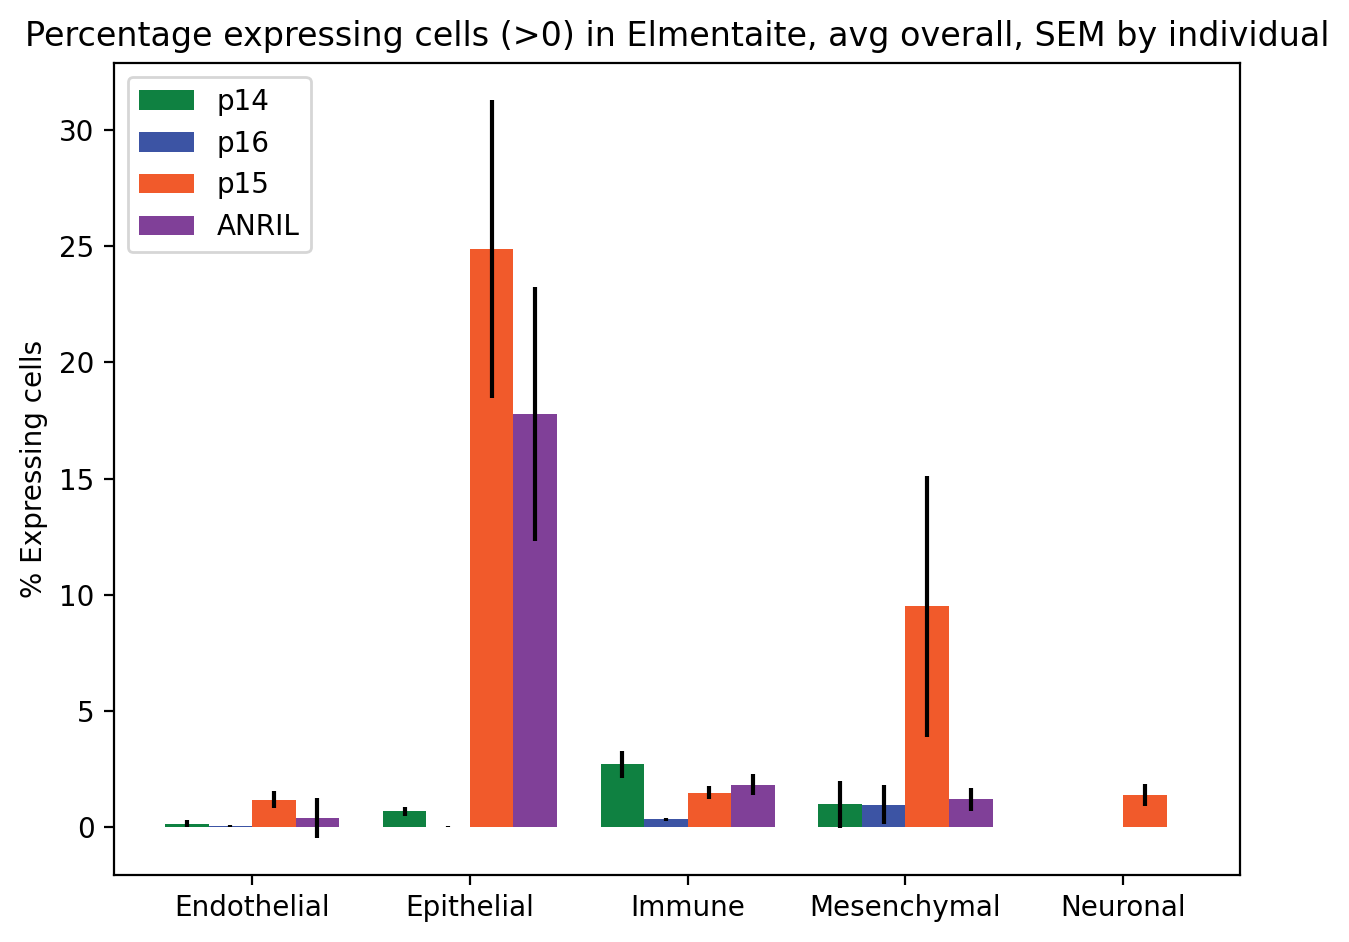

In [75]:
groups = ['Endothelial', 'Epithelial', 'Immune', 'Mesenchymal', 'Neuronal']

# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.2

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(percentage_above_threshold_p14.values), width, label='p14', yerr=grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(percentage_above_threshold_p16.values), width, label='p16', yerr=grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(percentage_above_threshold_p15.values), width, label='p15', yerr=grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(percentage_above_threshold_ANRIL.values), width, label='ANRIL', yerr=grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('% Expressing cells')
ax.set_title('Percentage expressing cells (>0) in Elmentaite, avg overall, SEM by individual')
ax.legend()

plt.tight_layout()

plt.savefig("figures/Elmentaite_PercentExpressing_GroupedBarplot_NewCols_avgoverallSEMdonors.pdf", format='pdf', dpi=300)
plt.show()

In [76]:
only_immune=genedf_adult[genedf_adult['category2'] =='Immune']

In [77]:
only_immune

,Sample name,Region,Region code,Fraction,category,Integrated_05,Age_group,Age,Diagnosis,CDKN2A,CDKN2A_p14,CDKN2A_p16,CDKN2B_p15,CDKN2BAS1_ANRIL,CDKN2B,CDKN2B-AS1,category2
AAAGTAGGTAGCAAAT-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
AACACGTAGAGCCCAA-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
AACTCTTGTTAAGAAC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
AACTGGTCAGACGTAG-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
AATCCAGAGGATGGTC-1-Human_colon_16S8000511,A32 (411C),LargeInt,SCL,SC-45N,Plasma cells,IgA plasma cell,Adult,25-30,Healthy adult,0.404558,0.0,1.0,0.0,0.0,0.0,0.0,Immune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACAAGGTTTC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,ILC3,Adult_MLN,70-75,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCACAGGAACGT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,SELL+ CD4 T,Adult_MLN,70-75,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCAGTTGTCTTT-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,B cells,Memory B,Adult_MLN,70-75,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune
TTTGTCATCGTTTATC-1-Human_colon_16S8117828,A26 (386C),lymph node,MLN,SC,T cells,Treg,Adult_MLN,70-75,Healthy adult,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,Immune


In [78]:
only_immune['category']=only_immune['category'].cat.remove_unused_categories()

/local/scratch/53150500.1.broad/ipykernel_90972/3802774958.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_immune['category']=only_immune['category'].cat.remove_unused_categories()


In [79]:
new_order=['T cells', 'B cells', 'Plasma cells', 'Myeloid']
only_immune['category'] = only_immune['category'].cat.reorder_categories(new_order, ordered=True)


/local/scratch/53150500.1.broad/ipykernel_90972/1247713280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  only_immune['category'] = only_immune['category'].cat.reorder_categories(new_order, ordered=True)


In [83]:
imm_total_counts = only_immune.groupby('category').size()
imm_total_counts

category
T cells         13069
B cells          4086
Plasma cells    14361
Myeloid          1795
dtype: int64

In [84]:
imm_total_counts_bysamp = only_immune.pivot_table(index='category', columns='Sample name', aggfunc='size')
imm_total_counts_bysamp

Sample name,A26 (386C),A32 (411C),A34 (417C),A38 (432C),A39 (440C)
category,,,,,
T cells,3119,713,764,1404,7069
B cells,887,417,537,175,2070
Plasma cells,1201,9649,3161,196,154
Myeloid,117,929,414,174,161


In [85]:
# Count rows where Value > threshold per Category
imm_above_threshold_counts_p14 = only_immune[only_immune['CDKN2A_p14'] > 0].groupby('category').size()

# Calculate percentage of rows > threshold per Category
imm_percentage_above_threshold_p14 = (imm_above_threshold_counts_p14 / imm_total_counts) * 100

# Count rows per Subgroup for each Category
imm_above_threshold_counts_p14_bysamp = only_immune[only_immune['CDKN2A_p14'] > 0].pivot_table(index='category', columns='Sample name', aggfunc='size', fill_value=0)

imm_percentage_above_threshold_p14_bysamp=imm_above_threshold_counts_p14_bysamp/imm_total_counts_bysamp*100
imm_percentage_above_threshold_p14_bysamp

imm_grouped_errors_p14_sem = imm_percentage_above_threshold_p14_bysamp.sem(axis=1)


In [86]:
# Count rows where Value > threshold per Category
imm_above_threshold_counts_p16 = only_immune[only_immune['CDKN2A_p16'] > 0].groupby('category').size()

# Calculate percentage of rows > threshold per Category
imm_percentage_above_threshold_p16 = (imm_above_threshold_counts_p16 / imm_total_counts) * 100

# Count rows per Subgroup for each Category
imm_above_threshold_counts_p16_bysamp = only_immune[only_immune['CDKN2A_p16'] > 0].pivot_table(index='category', columns='Sample name', aggfunc='size', fill_value=0)

imm_percentage_above_threshold_p16_bysamp=imm_above_threshold_counts_p16_bysamp/imm_total_counts_bysamp*100
imm_percentage_above_threshold_p16_bysamp

imm_grouped_errors_p16_sem = imm_percentage_above_threshold_p16_bysamp.sem(axis=1)

In [87]:
# Count rows where Value > threshold per Category
imm_above_threshold_counts_p15 = only_immune[only_immune['CDKN2B'] > 0].groupby('category').size()

# Calculate percentage of rows > threshold per Category
imm_percentage_above_threshold_p15 = (imm_above_threshold_counts_p15 / imm_total_counts) * 100

# Count rows per Subgroup for each Category
imm_above_threshold_counts_p15_bysamp = only_immune[only_immune['CDKN2B'] > 0].pivot_table(index='category', columns='Sample name', aggfunc='size', fill_value=0)

imm_percentage_above_threshold_p15_bysamp=imm_above_threshold_counts_p15_bysamp/imm_total_counts_bysamp*100
imm_percentage_above_threshold_p15_bysamp

imm_grouped_errors_p15_sem = imm_percentage_above_threshold_p15_bysamp.sem(axis=1)

In [88]:
# Count rows where Value > threshold per Category
imm_above_threshold_counts_ANRIL = only_immune[only_immune['CDKN2B-AS1'] > 0].groupby('category').size()

# Calculate percentage of rows > threshold per Category
imm_percentage_above_threshold_ANRIL = (imm_above_threshold_counts_ANRIL / imm_total_counts) * 100

# Count rows per Subgroup for each Category
imm_above_threshold_counts_ANRIL_bysamp = only_immune[only_immune['CDKN2B-AS1'] > 0].pivot_table(index='category', columns='Sample name', aggfunc='size', fill_value=0)

imm_percentage_above_threshold_ANRIL_bysamp=imm_above_threshold_counts_ANRIL_bysamp/ imm_total_counts_bysamp*100
imm_percentage_above_threshold_ANRIL_bysamp

imm_grouped_errors_ANRIL_sem = imm_percentage_above_threshold_ANRIL_bysamp.sem(axis=1)


In [89]:
imm_grouped_errors_ANRIL_sem

category
T cells         0.115622
B cells         0.361244
Plasma cells    0.292179
Myeloid         0.198896
dtype: float64

In [93]:
'T cells','B cells','Plasma cells','Myeloid'

('T cells', 'B cells', 'Plasma cells', 'Myeloid')

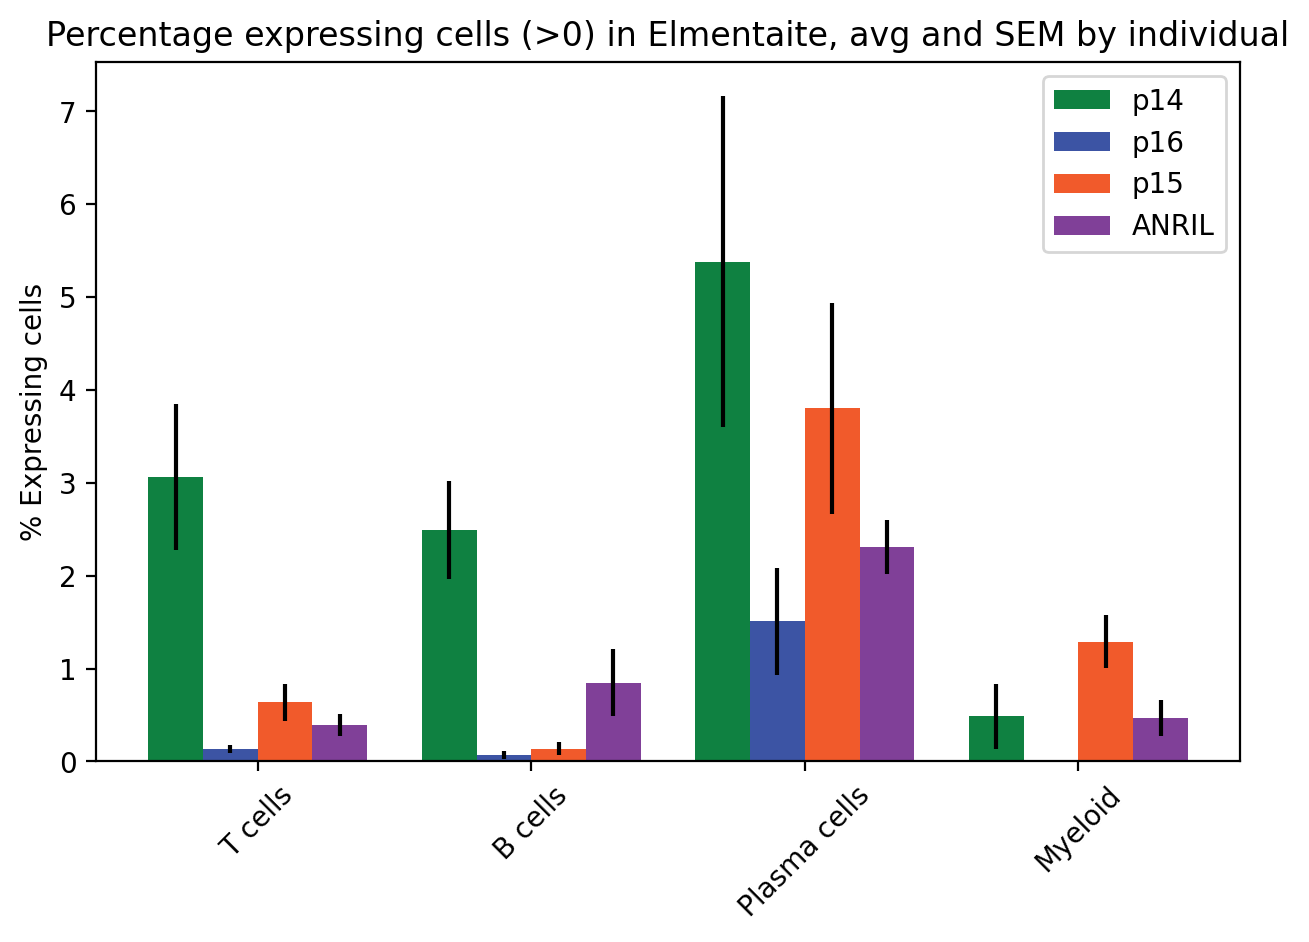

In [95]:
groups = ['T cells','B cells','Plasma cells','Myeloid']

# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.2

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(imm_percentage_above_threshold_p14_bysamp.mean(axis=1).values), width, label='p14', yerr=imm_grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(imm_percentage_above_threshold_p16_bysamp.mean(axis=1).values), width, label='p16', yerr=imm_grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(imm_percentage_above_threshold_p15_bysamp.mean(axis=1).values), width, label='p15', yerr=imm_grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(imm_percentage_above_threshold_ANRIL_bysamp.mean(axis=1).values), width, label='ANRIL', yerr=imm_grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
plt.xticks(rotation=45)
ax.set_ylabel('% Expressing cells')
ax.set_title('Percentage expressing cells (>0) in Elmentaite, avg and SEM by individual')
ax.legend()

plt.tight_layout()

plt.savefig("figures/Elmentaite_PercentExpressing_GroupedBarplot_onlyImmune_NewCols_avgSEMdonors.pdf", format='pdf', dpi=300)
plt.show()

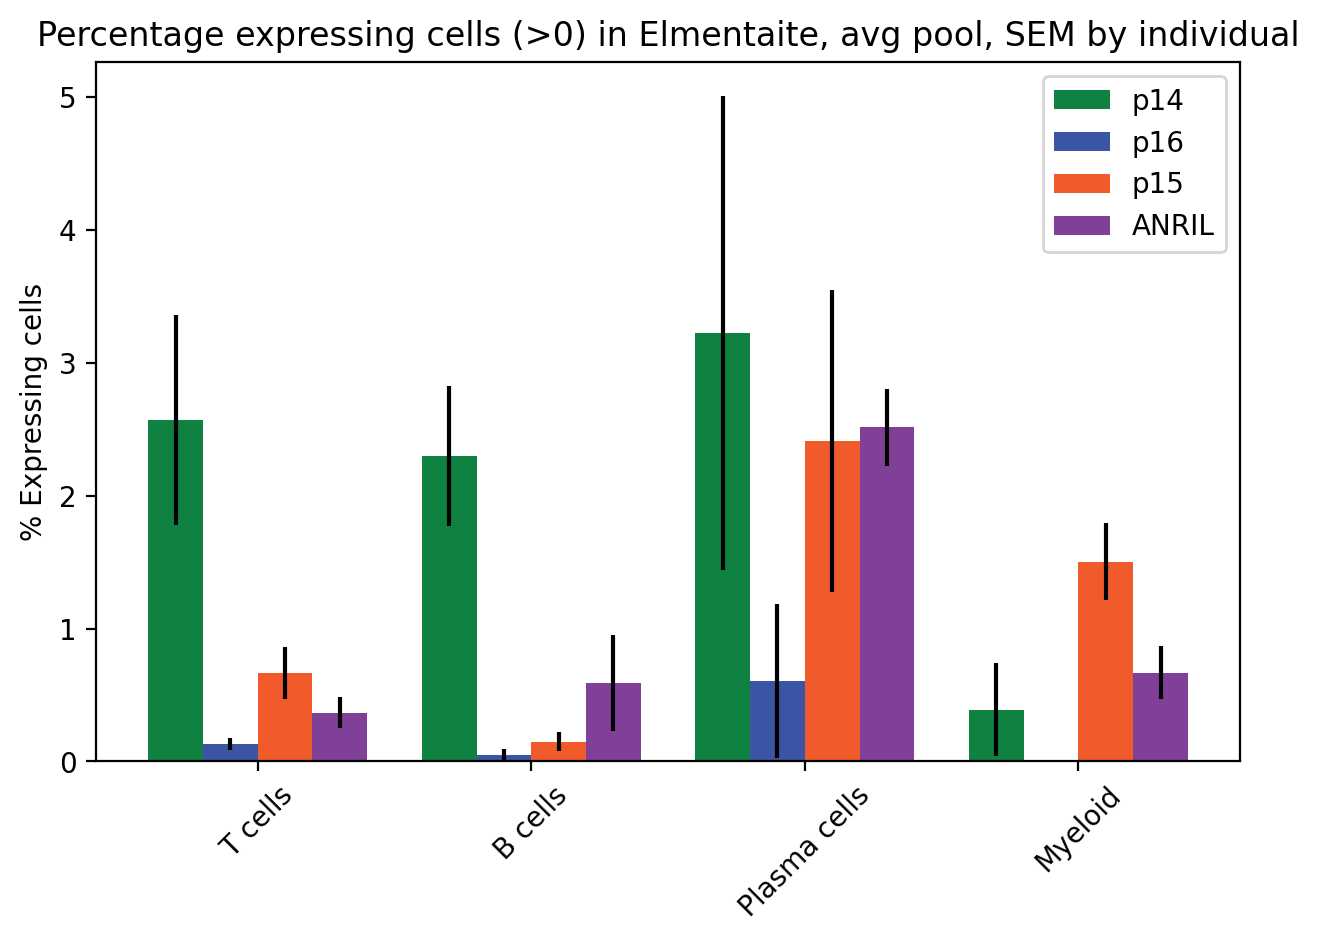

In [94]:
groups = ['T cells','B cells','Plasma cells','Myeloid']

# Bar width and positions
x = np.arange(len(groups))  # [0, 1, 2, 3, 4]
width = 0.2

colors = ['#0F8141','#3C54A4', '#F15A2B', '#804098']

fig, ax = plt.subplots()
ax.bar(x - 1.5*width, np.array(imm_percentage_above_threshold_p14.values), width, label='p14', yerr=imm_grouped_errors_p14_sem,color=colors[0])
ax.bar(x - 0.5*width, np.array(imm_percentage_above_threshold_p16.values), width, label='p16', yerr=imm_grouped_errors_p16_sem,color=colors[1])
ax.bar(x + 0.5*width, np.array(imm_percentage_above_threshold_p15.values), width, label='p15', yerr=imm_grouped_errors_p15_sem,color=colors[2])
ax.bar(x + 1.5*width, np.array(imm_percentage_above_threshold_ANRIL.values), width, label='ANRIL', yerr=imm_grouped_errors_ANRIL_sem,color=colors[3])

ax.set_xticks(x)
ax.set_xticklabels(groups)
plt.xticks(rotation=45)
ax.set_ylabel('% Expressing cells')
ax.set_title('Percentage expressing cells (>0) in Elmentaite, avg pool, SEM by individual')
ax.legend()

plt.tight_layout()

plt.savefig("figures/Elmentaite_PercentExpressing_GroupedBarplot_onlyImmune_NewCols_avgoverallSEMdonors.pdf", format='pdf', dpi=300)
plt.show()

In [96]:
sc.logging.print_header()


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [99]:
import matplotlib
matplotlib.__version__

'3.6.3'